In [1]:
from dataclasses import asdict
from itertools import combinations
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = str(Path(analysis_directory.name) / "counts.zarr")
repack_store(f"{dataset}/data.zarr", repacked_counts, nthreads=2)
ds = scarf.mount_datastore(
    repacked_counts,
    at=str(Path(analysis_directory.name) / "clustering_analysis.zarr"),
    default_assay="RNA",
    nthreads=4,
    min_features_per_cell=10,
)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/artifacts/embedding//values: 1 / 1 complete

Repacking RNA/artifacts/dendrogram//data: 1 / 1 complete

...

Repacking RNA/artifacts/marker_table//7/stats: 1 / 1 complete

Repacking RNA/artifacts/marker_table//10/stats: 1 / 1 complete

Repacking RNA/artifacts/marker_table//11/stats: 1 / 1 complete

Repacking RNA/artifacts/marker_table//3/stats: 1 / 1 complete

  RNA/counts: shape=(5025, 33538), dtype=uint32, chunks=(5025, 4791), shards=(5025, 38328)


In [2]:
clustering_run = ds.pipeline.run(
    filtering={
        "method": "manual",
        "attrs": ["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
        "lows": [1000, 500, 0],
        "highs": [15000, 4000, 15],
    },
    hvg_count=500,
    pca_dims=15,
    neighbors_k=11,
    umap=False,
    leiden={"partitions": [0.3, 0.5, 0.8]},
    cell_cycle=False,
    paris=True,
    doublets=False,
    markers=False,
)
graph = clustering_run["connectivity_map"]
initialization = ds.build_embedding_initialization(clustering_run["pca"])
umap = ds.run_umap(
    graph,
    initialization,
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
)
umap_values = np.asarray(ds.load_artifact(umap)["values"][:])

Calculating feature statistics: 30 / 30 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Training UMAP: 150 / 150 complete

In [3]:
leiden_refs = {
    resolution: clustering_run[f"leiden_{resolution}"]
    for resolution in (0.3, 0.5, 0.8)
}
leiden_values = {
    resolution: np.asarray(ds.load_artifact(ref)["values"][:])
    for resolution, ref in leiden_refs.items()
}

pd.DataFrame(
    {
        resolution: pd.Series(values).value_counts()
        for resolution, values in leiden_values.items()
    }
).fillna(0).astype(int)

,0.3,0.5,0.8
1,722,694,354
2,237,28,368
3,1264,237,237
4,683,1004,708
5,285,317,553
6,317,539,462
7,142,142,287
8,263,263,356
9,15,378,144
10,12,311,151


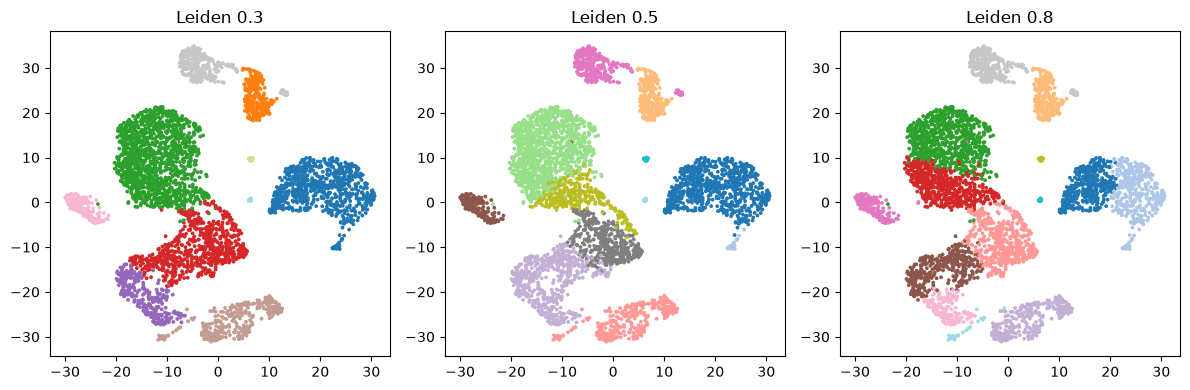

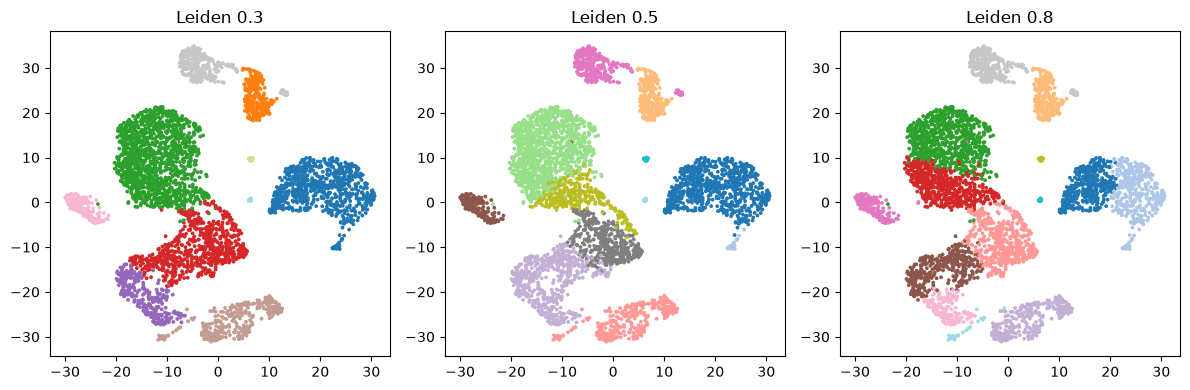

In [4]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, resolution in zip(axes, leiden_values, strict=True):
    axis.scatter(
        umap_values[:, 0],
        umap_values[:, 1],
        c=leiden_values[resolution],
        s=3,
        cmap="tab20",
    )
    axis.set_title(f"Leiden {resolution}")
figure.tight_layout()
figure

In [5]:
agreement = []
for first, second in combinations(leiden_values, 2):
    agreement.append(
        {
            "comparison": f"{first} vs {second}",
            "ARI": adjusted_rand_score(
                leiden_values[first],
                leiden_values[second],
            ),
            "NMI": normalized_mutual_info_score(
                leiden_values[first],
                leiden_values[second],
            ),
        }
    )
pd.DataFrame(agreement)

,comparison,ARI,NMI
0,0.3 vs 0.5,0.770245,0.878099
1,0.3 vs 0.8,0.647471,0.852723
2,0.5 vs 0.8,0.674633,0.847042


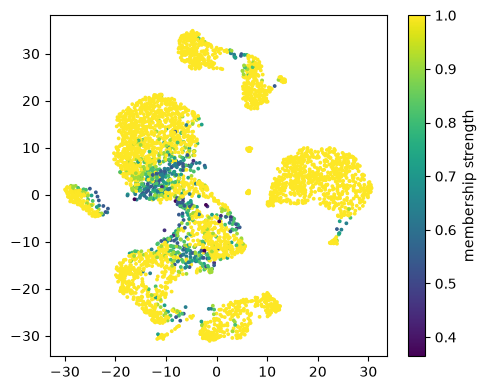

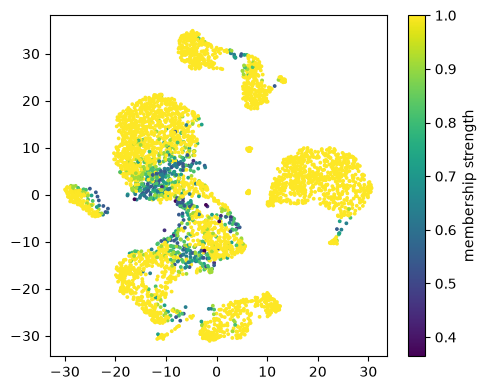

In [6]:
chosen = leiden_refs[0.5]
chosen_values = leiden_values[0.5]
membership = ds.calc_membership_strength(chosen, graph)
membership_values = np.asarray(ds.load_artifact(membership)["values"][:])

figure, axis = plt.subplots(figsize=(5, 4))
points = axis.scatter(
    umap_values[:, 0],
    umap_values[:, 1],
    c=membership_values,
    s=3,
)
figure.colorbar(points, ax=axis, label="membership strength")
figure.tight_layout()
figure

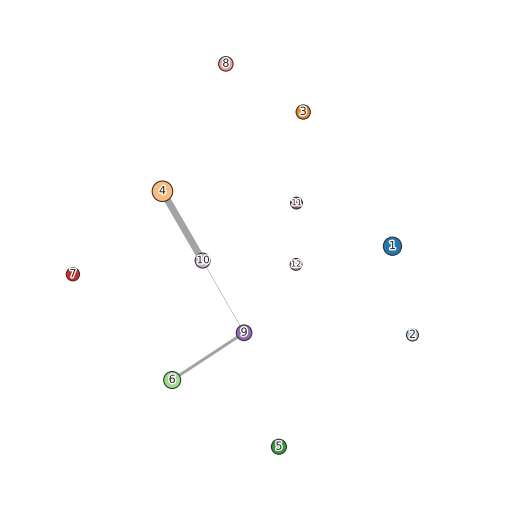

In [7]:
ds.plots.cluster_connectivity(
    graph=graph,
    groups=chosen,
    layout=umap,
)

In [8]:
paris_auto = clustering_run["paris"]
paris_result = ds.load_paris_clustering(paris_auto)
pd.DataFrame([asdict(item) for item in paris_result.diagnostics])[
    ["label", "size", "persistence", "decision_margin", "forced"]
]

,label,size,persistence,decision_margin,forced
0,1,337,79.705419,0.065040,False
1,2,385,89.092184,0.055471,False
2,3,257,132.482178,0.418605,False
3,4,1269,315.001767,0.067197,False
4,5,317,147.956538,0.164591,False
5,6,558,77.990342,NaN,False
6,7,137,97.023762,0.602801,False
7,8,243,100.905112,0.219834,False
8,9,410,128.162219,0.131857,False
9,10,15,NaN,NaN,True


Constructing graph from dendrogram: 3939 / 3939 complete

Identifying the top node for cluster: 1 / 1 complete

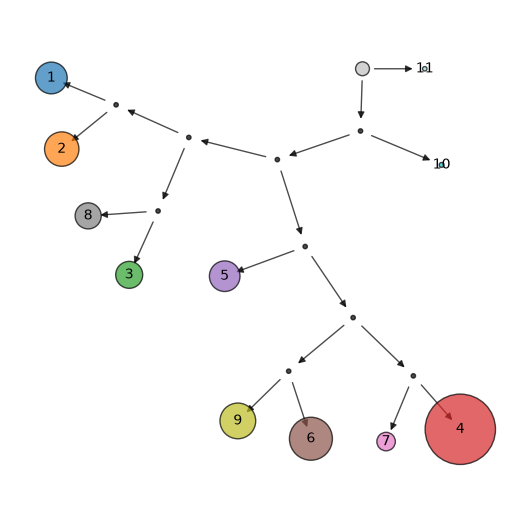

In [9]:
ds.plots.cluster_tree(graph=graph, clusters=paris_auto)

In [10]:
paris_fixed = ds.run_paris_clustering(
    graph,
    n_clusters=paris_result.n_clusters,
)
paris_auto_values = np.asarray(ds.load_artifact(paris_auto)["labels"][:])
paris_fixed_values = np.asarray(ds.load_artifact(paris_fixed)["labels"][:])
pd.Series(
    {
        "auto vs fixed ARI": adjusted_rand_score(
            paris_auto_values,
            paris_fixed_values,
        ),
        "Leiden vs Paris ARI": adjusted_rand_score(
            chosen_values,
            paris_auto_values,
        ),
    }
)

auto vs fixed ARI      0.731157
Leiden vs Paris ARI    0.736240
dtype: float64

In [11]:
all_features = ds.set_feature_selection(
    from_assay="RNA",
    feature_indexes=range(ds.RNA.feats.N),
)
markers = ds.run_marker_search(chosen, features=all_features)
sizes = pd.Series(chosen_values).value_counts()
largest = sizes.index[0]
smallest = sizes.index[-1]

largest_markers = ds.get_markers(marker=markers, group_id=largest)
smallest_markers = ds.get_markers(marker=markers, group_id=smallest)

Finding markers: 2 / 2 complete

In [12]:
largest_markers[
    ["feature_name", "score", "auc", "p_value", "p_value_adjusted"]
].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,ADTRP,0.41057,0.60208,2.122675e-83,3.727239e-81
1,FHIT,0.34388,0.75649,1.297768e-216,1.554448e-213
2,TSHZ2,0.31510,0.62291,4.188060e-84,7.471232e-82
3,CMTM8,0.31237,0.61065,2.354141e-65,2.892058e-63
4,EPHX2,0.31103,0.64836,3.218353e-101,7.709795e-99
5,LRRN3,0.30605,0.72201,1.099399e-191,9.703067e-189
6,CHRM3-AS2,0.30605,0.64164,3.369847e-97,7.435389e-95
7,NOG,0.30290,0.61092,1.214071e-91,2.482776e-89
8,MAN1C1,0.30181,0.60891,1.353549e-59,1.363223e-57
9,GSTM3,0.30174,0.60525,3.537595e-62,3.994743e-60


In [13]:
smallest_markers[
    ["feature_name", "score", "auc", "p_value", "p_value_adjusted"]
].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,F13A1,0.81787,0.99998,2.737010e-45,4.477748e-43
1,ACRBP,0.80562,0.95774,2.061862e-132,6.286431e-130
2,PTGS1,0.79792,0.99998,2.044860e-73,5.042684e-71
3,PRKAR2B,0.79786,1.00000,2.000594e-184,1.016605e-181
4,AP003068.2,0.79489,0.95765,1.075183e-118,3.004959e-116
5,TST,0.79442,0.95476,2.582438e-41,4.124276e-39
6,CD9,0.79128,0.99992,8.068113e-78,2.049912e-75
7,HIST1H3H,0.78964,0.95730,1.836591e-99,5.007773e-97
8,CLU,0.78698,1.00000,2.078877e-194,1.106689e-191
9,HIST1H2BJ,0.78389,0.87170,5.732431e-54,9.808892e-52
